# 📌 Baseline GLM (logit + Tweedie)

This notebook is part of the open-source companion materials for the conference session **“Practical FFNNs in Actuarial Work: GLMs, FFNNs, and Hybrid Alternatives.”**  
Source code, slides, and governance one-pager: **GitHub** → `Arocha-Associates/practical_ffnn` (see repository README).

---

### Purpose
Build the **audit-ready baseline** using:
- **Incidence**: sparse, regularised **logit GLM** (one-hot + scaling)
- **Severity**: **Tweedie GLM** with log link (positive, heavy-tail-aware)

This baseline serves as the benchmark for FFNN lift and hybrid attribution.

### Inputs
- `idi_exposure_synth_v1.csv`
- `idi_claims_synth_v1.csv`

### Outputs (saved to `OUT_DIR` / artifacts folder)
- Incidence results table (test window)
- Lift/capture curve (deciles)
- Calibration curve (zoomed for rare events)
- Severity plots (log1p actual vs predicted, tail view)
- Aggregate adequacy (PP and O/E)
- Segment adequacy table and heatmap (Region × Season)

### Required artifact exports (for Notebook 05)
At the end of this notebook, run the **GLM export cell** to write:
- `outputs_artifacts/glm_test_exposure_scored.csv`
- `outputs_artifacts/glm_test_claims_scored.csv`

### Recommended run order
1) **Notebook 03 (this GLM baseline)**  
2) Notebook 04 (FFNN challenger)  
3) Notebook 05 (scorecard from artifacts)

Governance note: all evaluations use a **time split** (train earlier months, test later months) and must reconcile to **pure premium and O/E**.

In [ ]:
# Common setup

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from pathlib import Path

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MaxAbsScaler
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_absolute_error

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True)

def make_ohe_dense(drop=None):
    
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)

def make_ohe_sparse(drop=None):
    
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, drop=drop)


In [17]:
# Paths

PROJECT_ROOT = Path("C:/Users/ca/OneDrive/Documents/@ CA/@ PROJECTS/FFNNs/IDS 2026")

EXPOSURE_CSV = f"{PROJECT_ROOT}/data/raw/idi_exposure_synth_v1.csv"
CLAIMS_CSV   = f"{PROJECT_ROOT}/data/raw/idi_claims_synth_v1.csv"

OUT_DIR = "outputs_figures"
os.makedirs(OUT_DIR, exist_ok=True)

EXPOSURE_CSV, CLAIMS_CSV, OUT_DIR

('C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_exposure_synth_v1.csv',
 'C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_claims_synth_v1.csv',
 'outputs_figures')

In [ ]:
# Load data

expo_df = pd.read_csv(EXPOSURE_CSV, parse_dates=["month_start"])
claims_df = pd.read_csv(CLAIMS_CSV, parse_dates=["month_start"])

print("Exposure rows:", len(expo_df), "| columns:", expo_df.shape[1])
print("Claims rows  :", len(claims_df), "| columns:", claims_df.shape[1])

# quick schema checks
for c in ["life_id","month_start","exposure_months","onset"]:
    assert c in expo_df.columns, f"Missing in exposure: {c}"
for c in ["claim_id","month_start","total_paid_ultimate"]:
    assert c in claims_df.columns, f"Missing in claims: {c}"


Exposure rows: 144000 | columns: 35
Claims rows  : 1565 | columns: 37


In [ ]:
# Time split (last N months as test)

N_TEST_MONTHS = 6
months_sorted = np.sort(expo_df["month_start"].unique())
cutoff = months_sorted[-N_TEST_MONTHS]

train_expo = expo_df[expo_df["month_start"] < cutoff].copy()
test_expo  = expo_df[expo_df["month_start"] >= cutoff].copy()
train_claims = claims_df[claims_df["month_start"] < cutoff].copy()
test_claims  = claims_df[claims_df["month_start"] >= cutoff].copy()

print("Test starts:", pd.to_datetime(cutoff).date())
print("Train exposure:", len(train_expo), " Test exposure:", len(test_expo))
print("Train claims:", len(train_claims), " Test claims:", len(test_claims))
assert len(train_claims) > 0 and len(test_claims) > 0, "Train/test claims split is empty."


Test starts: 2023-07-01
Train exposure: 108000  Test exposure: 36000
Train claims: 1181  Test claims: 384


In [ ]:
# Feature set (match project notebooks)

cat_cols = [
    "region","occ","employer","plan",
    "sex","smoker","bmi_band","salary_band",
    "underwriting_class","elim_period","benefit_period","season"
]
num_cols = [
    "age","chronic_resp_flag","chronic_cardio_flag","prior_claim_flag","cola_flag",
    "monthly_benefit_cap",
    "heat_index_30d","smoke_pm25_30d","flood_flag_30d",
    "compound_heat_smoke","extreme_heat"
]
X_cols = cat_cols + num_cols
missing = [c for c in X_cols if c not in expo_df.columns]
assert not missing, f"Missing features: {missing}"


In [21]:
# Fit GLM incidence (logit)

preproc = ColumnTransformer(
    transformers=[
        ("cat", make_ohe_sparse(), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

glm_inc = Pipeline(steps=[
    ("prep", preproc),
    ("scale_all", MaxAbsScaler()),
    ("clf", LogisticRegression(
        solver="saga", penalty="l2", C=1.0,
        max_iter=2000, tol=1e-4, n_jobs=-1, random_state=7
    ))
])

glm_inc.fit(train_expo[X_cols], train_expo["onset"].values)
p_glm = glm_inc.predict_proba(test_expo[X_cols])[:, 1]
yte_inc = test_expo["onset"].values

inc_metrics = pd.DataFrame([{
    "Observed rate": float(yte_inc.mean()),
    "Mean predicted p": float(p_glm.mean()),
    "AUC": roc_auc_score(yte_inc, p_glm),
    "PR-AUC": average_precision_score(yte_inc, p_glm),
    "Brier (↓)": brier_score_loss(yte_inc, p_glm),
}])
display(inc_metrics.style.format({"Observed rate":"{:.6f}","Mean predicted p":"{:.6f}","AUC":"{:.4f}","PR-AUC":"{:.6f}","Brier (↓)":"{:.6f}"}))


,Observed rate,Mean predicted p,AUC,PR-AUC,Brier (↓)
0,0.010667,0.012385,0.6065,0.016580,0.010627


In [ ]:
# Expected Calibration Error

def calibration_bins_quantile(y_true, p_hat, n_bins=10):
    """
    Quantile-binned calibration table + ECE/MCE.
    Uses equal-count bins (good for rare events).
    """
    y_true = np.asarray(y_true).astype(float)
    p_hat = np.asarray(p_hat).astype(float)

    # Quantile edges; ensure uniqueness to avoid empty/duplicate bins
    edges = np.quantile(p_hat, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        raise ValueError("Not enough unique probabilities to form calibration bins.")

    # Assign bins
    # bins are [edges[i], edges[i+1]] with right-closed on last
    bin_idx = np.digitize(p_hat, edges[1:-1], right=True)

    rows = []
    N = len(p_hat)
    for b in range(len(edges) - 1):
        m = bin_idx == b
        if m.sum() == 0:
            continue
        pred = float(p_hat[m].mean())
        obs = float(y_true[m].mean())
        n = int(m.sum())
        rows.append({"bin": b+1, "n": n, "pred_mean": pred, "obs_rate": obs, "abs_gap": abs(obs - pred)})

    cal = pd.DataFrame(rows)
    cal["weight"] = cal["n"] / N

    ece = float((cal["weight"] * cal["abs_gap"]).sum())
    mce = float(cal["abs_gap"].max())

    return cal, ece, mce, edges

cal_tbl, ece_glm, mce_glm, bin_edges = calibration_bins_quantile(yte_inc, p_glm, n_bins=10)

print(f"Observed rate: {yte_inc.mean():.6f}")
print(f"Mean predicted p: {p_glm.mean():.6f}")
print(f"ECE (↓): {ece_glm:.6f}")
print(f"MCE (↓): {mce_glm:.6f}")

display(cal_tbl)

Observed rate: 0.010667
Mean predicted p: 0.012385
ECE (↓): 0.004776
MCE (↓): 0.020410


,bin,n,pred_mean,obs_rate,abs_gap,weight
0,1,3600,0.002024,0.006667,0.004643,0.1
1,2,3600,0.003497,0.008611,0.005114,0.1
2,3,3600,0.004676,0.007500,0.002824,0.1
3,4,3600,0.005951,0.006111,0.000160,0.1
4,5,3600,0.007419,0.007500,0.000081,0.1
5,6,3600,0.009203,0.011667,0.002464,0.1
6,7,3600,0.011595,0.009722,0.001872,0.1
7,8,3600,0.015165,0.011389,0.003776,0.1
8,9,3600,0.021135,0.014722,0.006413,0.1
9,10,3600,0.043188,0.022778,0.020410,0.1


'outputs_figures\\glm_incidence_lift_curve.svg'

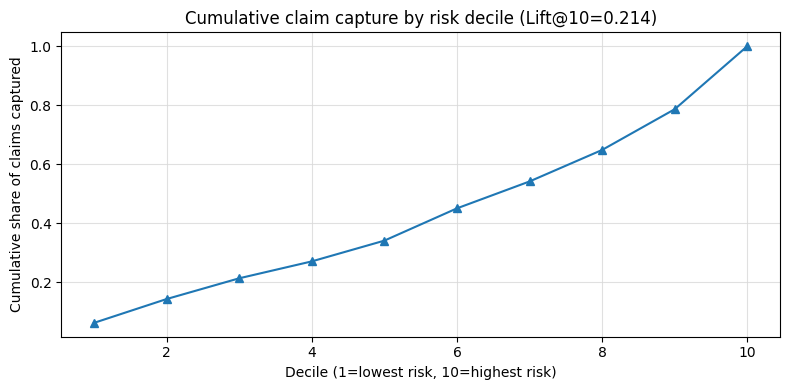

In [ ]:
# Lift@10 curve

def top_decile_capture(y_true, p_hat, frac=0.10):
    k = max(1, int(frac * len(p_hat)))
    idx = np.argsort(p_hat)[-k:]
    return float(y_true[idx].sum() / max(1, y_true.sum()))

lift10 = top_decile_capture(yte_inc, p_glm, 0.10)

df = pd.DataFrame({"y": yte_inc, "p": p_glm})
df["decile"] = pd.qcut(df["p"], 10, labels=False, duplicates="drop")
cap = df.groupby("decile")["y"].sum().reset_index()
cap["cum_claims"] = cap["y"].cumsum()
cap["cum_claim_share"] = cap["cum_claims"] / cap["y"].sum()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(np.arange(1, len(cap)+1), cap["cum_claim_share"], marker="^")
ax.set_title(f"Cumulative claim capture by risk decile (Lift@10={lift10:.3f})")
ax.set_xlabel("Decile (1=lowest risk, 10=highest risk)")
ax.set_ylabel("Cumulative share of claims captured")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "glm_incidence_lift_curve.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path


'outputs_figures\\glm_incidence_calibration_curve.svg'

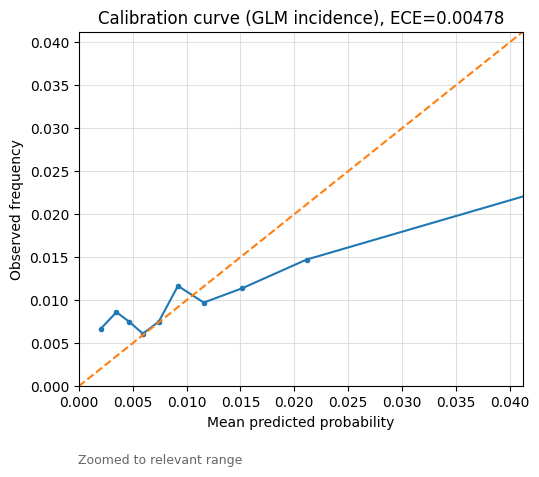

In [24]:
# Calibration curve (reliability)

prob_true, prob_pred = calibration_curve(yte_inc, p_glm, n_bins=10, strategy="quantile")

obs = float(np.mean(prob_true))
p99 = float(np.quantile(prob_pred, 0.99))
upper = max(3*obs, p99)     
upper = min(upper, 0.10)    

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.plot(prob_pred, prob_true, marker=".")
ax.plot([0, upper], [0, upper], linestyle="--")
ax.set_title(f"Calibration curve (GLM incidence), ECE={ece_glm:.5f}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.margins(x=0, y=0)          

fig.subplots_adjust(bottom=0.18)

fig.text(
    0.15, -0.05,
    "Zoomed to relevant range",
    ha="left", va="bottom",
    fontsize=9, color="#666666"
)

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "glm_incidence_calibration_curve.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

In [ ]:
# GLM severity (Tweedie)

glm_sev = Pipeline(steps=[
    ("prep", preproc),
    ("scale_all", MaxAbsScaler()),
    ("twd", TweedieRegressor(power=1.5, alpha=1e-4, link="log", max_iter=1200)),
])

glm_sev.fit(train_claims[X_cols], train_claims["total_paid_ultimate"].values.astype(float))
sev_claims = np.clip(glm_sev.predict(test_claims[X_cols]), 1.0, None)
yte_sev = test_claims["total_paid_ultimate"].values.astype(float)

sev_mae = float(mean_absolute_error(yte_sev, sev_claims))
sev_rmse_log1p = float(np.sqrt(np.mean((np.log1p(yte_sev) - np.log1p(sev_claims))**2)))
q90 = np.quantile(yte_sev, 0.90)
tail = yte_sev >= q90
sev_tail_mae = float(mean_absolute_error(yte_sev[tail], sev_claims[tail]))

sev_metrics = pd.DataFrame([{
    "Mean actual (CHF)": float(yte_sev.mean()),
    "Mean predicted (CHF)": float(sev_claims.mean()),
    "MAE (CHF) (↓)": sev_mae,
    "RMSE log1p (↓)": sev_rmse_log1p,
    "Tail MAE P90+ (CHF) (↓)": sev_tail_mae,
}])
display(sev_metrics.style.format({"Mean actual (CHF)":"{:,.0f}","Mean predicted (CHF)":"{:,.0f}","MAE (CHF) (↓)":"{:,.0f}","RMSE log1p (↓)":"{:.4f}","Tail MAE P90+ (CHF) (↓)":"{:,.0f}"}))

,Mean actual (CHF),Mean predicted (CHF),MAE (CHF) (↓),RMSE log1p (↓),Tail MAE P90+ (CHF) (↓)
0,"106,135","106,932","47,339",0.5587,"89,130"


'outputs_figures\\glm_severity_actual_vs_pred_log1p.svg'

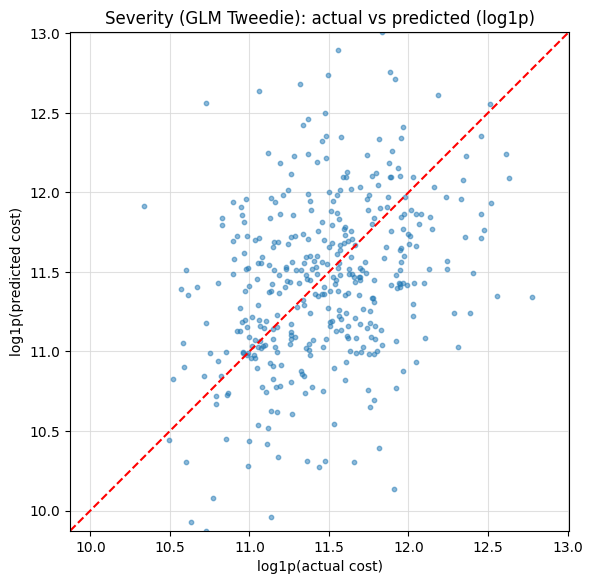

In [26]:
# Actual vs predicted severity (log1p)

x = np.log1p(yte_sev)        # actual (log1p)
yhat = np.log1p(sev_claims)  # predicted (log1p)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x, yhat, s=10, alpha=0.5)
ax.set_title("Severity (GLM Tweedie): actual vs predicted (log1p)")
ax.set_xlabel("log1p(actual cost)")
ax.set_ylabel("log1p(predicted cost)")

mn = min(x.min(), yhat.min())
mx = max(x.max(), yhat.max())

ax.plot([mn, mx], [mn, mx], linestyle="--", color="red")
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "glm_severity_actual_vs_pred_log1p.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

'outputs_figures\\glm_severity_tail_actual_vs_pred_log1p.svg'

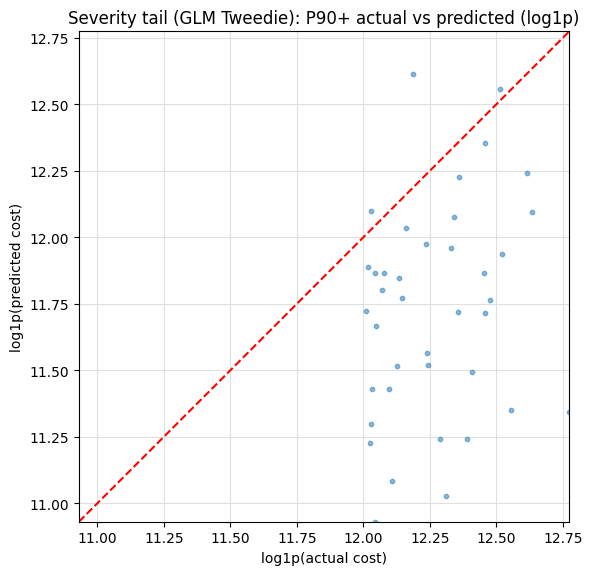

In [27]:
tail_y = yte_sev[tail]
tail_p = sev_claims[tail]

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(np.log1p(tail_y), np.log1p(tail_p), s=10, alpha=0.5)
ax.set_title("Severity tail (GLM Tweedie): P90+ actual vs predicted (log1p)")
ax.set_xlabel("log1p(actual cost)")
ax.set_ylabel("log1p(predicted cost)")

mn = min(np.log1p(tail_y).min(), np.log1p(tail_p).min())
mx = max(np.log1p(tail_y).max(), np.log1p(tail_p).max())

ax.plot([mn, mx], [mn, mx], linestyle="--", color="red")
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "glm_severity_tail_actual_vs_pred_log1p.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

In [ ]:
# Aggregate PP and O/E

sev_expo = np.clip(glm_sev.predict(test_expo[X_cols]), 1.0, None)
exp_total = float(np.sum(p_glm * sev_expo))
act_total = float(test_claims["total_paid_ultimate"].sum())
exp_months = float(test_expo["exposure_months"].sum())

pp_exp = exp_total / exp_months
pp_act = act_total / exp_months
oe = act_total / max(exp_total, 1e-12)

agg_tbl = pd.DataFrame([{
    "Expected total cost (CHF)": exp_total,
    "Actual total cost (CHF)": act_total,
    "Expected PP (CHF/exp-month)": pp_exp,
    "Actual PP (CHF/exp-month)": pp_act,
    "O/E (Actual ÷ Expected)": oe,
}])
display(agg_tbl.style.format({
    "Expected total cost (CHF)":"{:,.0f}","Actual total cost (CHF)":"{:,.0f}",
    "Expected PP (CHF/exp-month)":"{:,.2f}","Actual PP (CHF/exp-month)":"{:,.2f}",
    "O/E (Actual ÷ Expected)":"{:.4f}"
}))


,Expected total cost (CHF),Actual total cost (CHF),Expected PP (CHF/exp-month),Actual PP (CHF/exp-month),O/E (Actual ÷ Expected)
0,"47,182,238","40,755,967","1,310.62","1,132.11",0.8638


C:\Users\ca\AppData\Local\Temp\ipykernel_20980\1777985379.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = mpl.cm.get_cmap("RdYlGn_r", 256)


('outputs_figures\\glm_segment_oe_heatmaps_raw_vs_filtered.svg',
 'outputs_figures\\glm_segment_oe_table_all.csv',
 'outputs_figures\\glm_segment_oe_table_credible.csv')

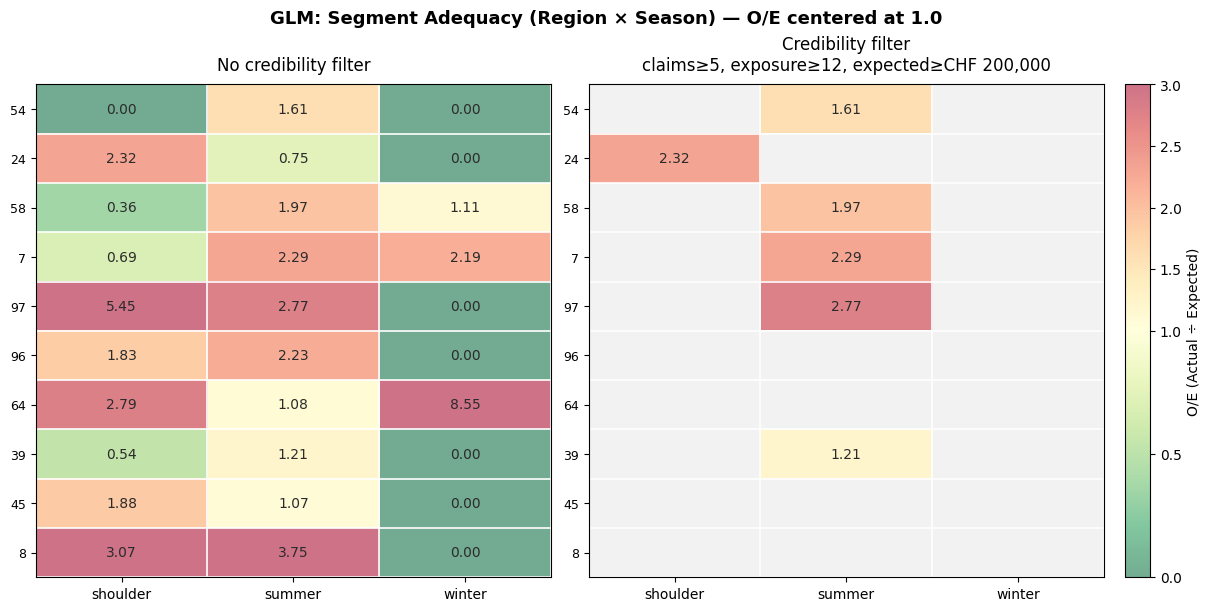

In [ ]:
# Segment O/E heatmaps

seg = test_expo.copy()
seg["p_glm"] = p_glm
seg["sev_glm_expo"] = sev_expo
seg["exp_cost"] = seg["p_glm"] * seg["sev_glm_expo"]

seg = seg.merge(test_claims[["claim_id", "total_paid_ultimate"]], on="claim_id", how="left")
seg["actual_cost"] = np.where(seg["onset"] == 1, seg["total_paid_ultimate"].fillna(0.0), 0.0)

seg_tbl = (
    seg.groupby(["region", "season"], as_index=False)
       .agg(
           exposure=("exposure_months", "sum"),
           claims=("onset", "sum"),
           actual=("actual_cost", "sum"),
           expected=("exp_cost", "sum"),
       )
)
seg_tbl["OE"] = seg_tbl["actual"] / np.clip(seg_tbl["expected"], 1e-9, None)

MIN_CLAIMS   = 5
MIN_EXPOSURE = 12
MIN_EXPECTED = 200_000

credible = (
    (seg_tbl["claims"]   >= MIN_CLAIMS) &
    (seg_tbl["exposure"] >= MIN_EXPOSURE) &
    (seg_tbl["expected"] >= MIN_EXPECTED)
)

seg_tbl["OE_filtered"] = np.where(credible, seg_tbl["OE"], np.nan)

top_regions = (
    seg_tbl.groupby("region")["claims"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

hm_raw = (
    seg_tbl[seg_tbl["region"].isin(top_regions)]
    .pivot(index="region", columns="season", values="OE")
    .reindex(index=top_regions)
)

hm_filt = (
    seg_tbl[seg_tbl["region"].isin(top_regions)]
    .pivot(index="region", columns="season", values="OE_filtered")
    .reindex(index=top_regions)
)

base = mpl.cm.get_cmap("RdYlGn_r", 256)
colors = base(np.linspace(0, 1, 256))
blend = 0.45  
colors[:, :3] = (1 - blend) * colors[:, :3] + blend * np.array([1, 1, 1])
pastel_cmap = LinearSegmentedColormap.from_list("pastel_div", colors)
pastel_cmap.set_bad(color="#F2F2F2")  

vals = hm_raw.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
q05, q95 = np.quantile(finite_vals, [0.05, 0.95])
spread = max(1.0 - q05, q95 - 1.0)
vmin, vmax = 1.0 - spread, 1.0 + spread
vmin = max(0.0, vmin)
vmax = min(3.0, vmax)
norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

panels = [
    ("No credibility filter", hm_raw),
    (f"Credibility filter\nclaims≥{MIN_CLAIMS}, exposure≥{MIN_EXPOSURE}, expected≥CHF {MIN_EXPECTED:,.0f}", hm_filt),
]

for ax, (title, hm) in zip(axes, panels):
    im = ax.imshow(hm.values, aspect="auto", cmap=pastel_cmap, norm=norm)
    ax.set_title(title, pad=10)

    ax.set_yticks(np.arange(hm.shape[0]))
    ax.set_yticklabels(hm.index, fontsize=9)

    ax.set_xticks(np.arange(hm.shape[1]))
    ax.set_xticklabels(hm.columns, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    # Cell borders
    ax.set_xticks(np.arange(-.5, hm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, hm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(hm.shape[0]):
        for j in range(hm.shape[1]):
            val = hm.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color="#2B2B2B")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label("O/E (Actual ÷ Expected)", rotation=90)

fig.suptitle("GLM: Segment Adequacy (Region × Season) — O/E centered at 1.0", fontsize=13, fontweight="semibold")

# Save
fig_path = os.path.join(OUT_DIR, "glm_segment_oe_heatmaps_raw_vs_filtered.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight", pad_inches=0.02)

# Export tables
out_csv_all  = os.path.join(OUT_DIR, "glm_segment_oe_table_all.csv")
out_csv_cred = os.path.join(OUT_DIR, "glm_segment_oe_table_credible.csv")
seg_tbl.to_csv(out_csv_all, index=False)
seg_tbl.loc[credible].to_csv(out_csv_cred, index=False)

(fig_path, out_csv_all, out_csv_cred)

In [30]:
# Export scored datasets for Notebook 05

ARTIFACT_DIR = "outputs_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# double-check expected variables from Notebook 03 before exporting
required = ["test_expo", "test_claims", "p_glm", "sev_expo", "sev_claims"]
missing = [v for v in required if v not in globals()]
assert not missing, f"Missing variables in Notebook 03: {missing}"

glm_expo_scored = test_expo[["life_id", "month_start", "exposure_months", "onset", "claim_id"]].copy()
glm_expo_scored["p_hat"] = p_glm
glm_expo_scored["sev_hat"] = sev_expo
glm_expo_scored["exp_cost"] = glm_expo_scored["p_hat"] * glm_expo_scored["sev_hat"]

glm_claims_scored = test_claims[["claim_id", "life_id", "month_start", "total_paid_ultimate"]].copy()
glm_claims_scored["sev_hat"] = sev_claims

glm_expo_path = os.path.join(ARTIFACT_DIR, "glm_test_exposure_scored.csv")
glm_claims_path = os.path.join(ARTIFACT_DIR, "glm_test_claims_scored.csv")

glm_expo_scored.to_csv(glm_expo_path, index=False)
glm_claims_scored.to_csv(glm_claims_path, index=False)

print("Wrote:")
print(" ", glm_expo_path)
print(" ", glm_claims_path)

Wrote:
  outputs_artifacts\glm_test_exposure_scored.csv
  outputs_artifacts\glm_test_claims_scored.csv
